# Example notebook: loading the dataset and training a simple PilotNet

This notebook shows how to:

1. Load the processed dataset generated by the preprocessing pipeline.
2. Inspect image tensors and normalized torque labels.
3. Split the dataset into training and validation sets.
4. Train a simple PilotNet model for a few epochs.
5. Evaluate the model on the validation set.

## Imports

In [2]:
import os
print("os OK")

os OK


In [1]:
import sys
print(sys.executable)

c:\Users\maria\Escritorio\Personal\TFG\pytorch_env\Scripts\python.exe


In [3]:
import torch
print(torch.__version__)

2.10.0+cpu


In [4]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader, random_split

## Load the processed dataset

In [5]:
dataset_path = "C:/Users/maria/Escritorio/Personal/TFG/processed_data.pt"

data = torch.load(dataset_path, map_location="cpu")

images = data["images"]
torques = data["torques"]
normalization_params = data["normalization_params"]
stats = data["original_stats"]

print("Images shape:", images.shape)
print("Torques shape:", torques.shape)
print("Normalization params:", normalization_params)
print("Original stats:", stats)

Images shape: torch.Size([125143, 3, 66, 200])
Torques shape: torch.Size([125143])
Normalization params: {'method': 'minmax_symmetric', 'min_torque': -1108.0, 'max_torque': 1920.0, 'range': 3028.0}
Original stats: {'min': -1108.0, 'max': 1920.0, 'mean': 73.79943084716797, 'std': 362.6117248535156}


## Quick inspection

In [6]:
print(f"Number of samples: {len(images)}")
print(f"Image tensor shape: {images[0].shape}")
print(f"First 5 torques: {torques[:5]}")

Number of samples: 125143
Image tensor shape: torch.Size([3, 66, 200])
First 5 torques: tensor([-0.2034, -0.2034, -0.2034, -0.2034, -0.2034])


## View some images

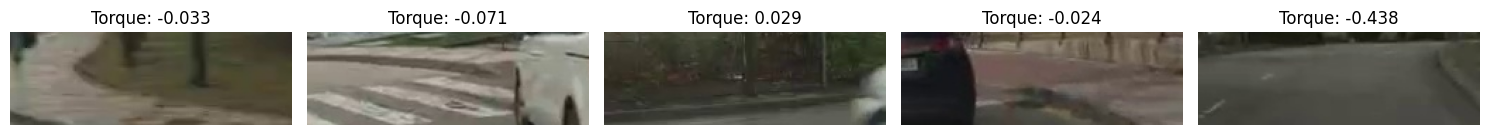

In [7]:
def show_samples(images, torques, num_samples=5):
    plt.figure(figsize=(15, 4))
    
    indices = random.sample(range(len(images)), num_samples)
    
    for i, idx in enumerate(indices):
        img = images[idx].permute(1, 2, 0).numpy()  # C,H,W -> H,W,C
        torque = torques[idx].item()
        
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"Torque: {torque:.3f}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_samples(images, torques, num_samples=5)

## Create dataset and train/valid partition

In [8]:
full_dataset = TensorDataset(images, torques)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Train samples: 100114
Validation samples: 25029


## Simple PilotNet

In [9]:
class PilotNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=5, stride=2),
            nn.ReLU(),
            nn.Conv2d(24, 36, kernel_size=5, stride=2),
            nn.ReLU(),
            nn.Conv2d(36, 48, kernel_size=5, stride=2),
            nn.ReLU(),
            nn.Conv2d(48, 64, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3),
            nn.ReLU()
        )
        
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 1 * 18, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, 10),
            nn.ReLU(),
            nn.Linear(10, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x.squeeze(1)

## Initialize model

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = PilotNet().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Using device: cpu


## Training

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    
    for imgs, targets in loader:
        imgs = imgs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    
    with torch.no_grad():
        for imgs, targets in loader:
            imgs = imgs.to(device)
            targets = targets.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * imgs.size(0)

    return running_loss / len(loader.dataset)

In [12]:
num_epochs = 5

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - Train loss: {train_loss:.6f} - Val loss: {val_loss:.6f}")

Epoch 1/5 - Train loss: 0.053459 - Val loss: 0.044326
Epoch 2/5 - Train loss: 0.041435 - Val loss: 0.036771
Epoch 3/5 - Train loss: 0.033172 - Val loss: 0.028745
Epoch 4/5 - Train loss: 0.026927 - Val loss: 0.023638
Epoch 5/5 - Train loss: 0.022839 - Val loss: 0.020500


## Loss graphs

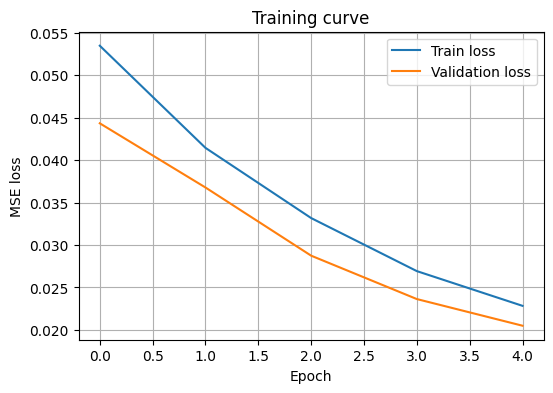

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training curve")
plt.legend()
plt.grid(True)
plt.show()

## Sample predictions

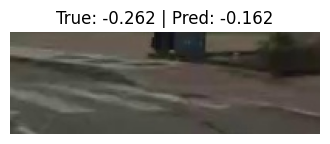

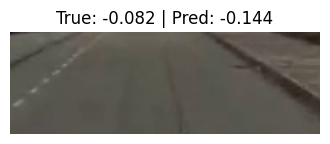

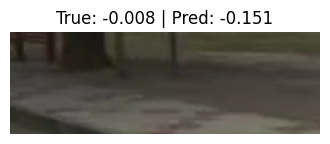

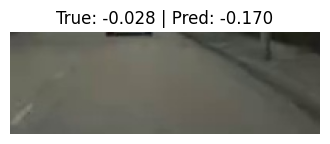

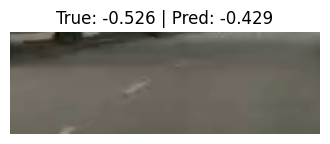

In [14]:
model.eval()

with torch.no_grad():
    imgs, targets = next(iter(val_loader))
    imgs = imgs.to(device)
    preds = model(imgs).cpu()

for i in range(5):
    img = imgs[i].cpu().permute(1, 2, 0).numpy()
    true_torque = targets[i].item()
    pred_torque = preds[i].item()

    plt.figure(figsize=(4, 2))
    plt.imshow(img)
    plt.title(f"True: {true_torque:.3f} | Pred: {pred_torque:.3f}")
    plt.axis("off")
    plt.show()